# [Dynamic Topic Modeling](https://maartengr.github.io/BERTopic/getting_started/topicsovertime/topicsovertime.html)

Dynamic topic modeling (DTM) is a collection of techniques aimed at analyzing the evolution of topics over time. These methods allow you to understand how a topic is represented across different times. For example, in 1995 people may talk differently about environmental awareness than those in 2015. Although the topic itself remains the same, environmental awareness, the exact representation of that topic might differ.

BERTopic allows for DTM by calculating the topic representation at each timestep without the need to run the entire model several times. To do this, we first need to fit BERTopic as if there were no temporal aspect in the data. Thus, a general topic model will be created. We use the global representation as to the main topics that can be found at, most likely, different timesteps. For each topic and timestep, we calculate the c-TF-IDF representation. This will result in a specific topic representation at each timestep without the need to create clusters from embeddings as they were already created.

Next, there are two main ways to further fine-tune these specific topic representations, namely globally and evolutionary.

A topic representation at timestep t can be fine-tuned globally by averaging its c-TF-IDF representation with that of the global representation. This allows each topic representation to move slightly towards the global representation whilst still keeping some of its specific words.

A topic representation at timestep t can be fine-tuned evolutionary by averaging its c-TF-IDF representation with that of the c-TF-IDF representation at timestep t-1. This is done for each topic representation allowing for the representations to evolve over time.

Both fine-tuning methods are set to True as a default and allow for interesting representations to be created.

## Example

To demonstrate DTM in BERTopic, we first need to prepare our data. A good example of where DTM is useful is topic modeling on Twitter data. We can analyze how certain people have talked about certain topics in the years they have been on Twitter. Due to the controversial nature of his tweets, we are going to be using all tweets by Donald Trump.

First, we need to load the data and do some very basic cleaning. For example, I am not interested in his re-tweets for this use-case:

In [1]:
import re
import pandas as pd

# Prepare data
trump = pd.read_csv('https://drive.google.com/uc?export=download&id=1xRKHaP-QwACMydlDnyFPEaFdtskJuBa6')
trump.text = trump.apply(lambda row: re.sub(r"http\S+", "", row.text).lower(), 1)
trump.text = trump.apply(lambda row: " ".join(filter(lambda x:x[0]!="@", row.text.split())), 1)
trump.text = trump.apply(lambda row: " ".join(re.sub("[^a-zA-Z]+", " ", row.text).split()), 1)
trump = trump.loc[(trump.isRetweet == "f") & (trump.text != ""), :]
timestamps = trump.date.to_list()
tweets = trump.text.to_list()

Then, we need to extract the global topic representations by simply creating and training a BERTopic model:

In [2]:
from bertopic import BERTopic

topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(tweets)

2025-03-12 15:14:08,453 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1418 [00:00<?, ?it/s]

2025-03-12 15:14:36,173 - BERTopic - Embedding - Completed ✓
2025-03-12 15:14:36,173 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2025-03-12 15:14:54,292 - BERTopic - Dimensionality - Completed ✓
2025-03-12 15:14:54,294 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the

From these topics, we are going to generate the topic representations at each timestamp for each topic. We do this by simply calling topics_over_time and passing the tweets, the corresponding timestamps, and the related topics:

In [3]:
topics_over_time = topic_model.topics_over_time(tweets, timestamps, nr_bins=20)

20it [00:07,  2.69it/s]


In [4]:
topics_over_time

,Topic,Words,Frequency,Timestamp
0,-1,"keychain, donald, contest, stuf, achiever",17,2009-04-30 12:30:07.597
1,0,"execute, imagination, direct, utilize, precipice",9,2009-04-30 12:30:07.597
2,3,"begun, schedule, ahead, international, scotland",1,2009-04-30 12:30:07.597
3,7,"apprentice, randal, pinkett, lieutenant, celeb...",3,2009-04-30 12:30:07.597
4,18,"ivanka, gma, jared, entrepreneurial, sharing",4,2009-04-30 12:30:07.597
...,...,...,...,...
4223,541,"rush, greatest, limbaugh, guy, is",1,2020-06-09 07:29:57.850
4224,542,"campaign, enthusiasm, spirit, books, written",1,2020-06-09 07:29:57.850
4225,546,"herschel, truth, speaking, dianemarshall, ukca...",1,2020-06-09 07:29:57.850
4226,547,"john, such, honor, thank, johndoe",1,2020-06-09 07:29:57.850


And that is it! Aside from what you always need for BERTopic, you now only need to add timestamps to quickly calculate the topics over time

## Parameters
There are a few parameters that are of interest which will be discussed below.

### Tuning
Both global_tuning and evolutionary_tuning are set to True as a default, but can easily be changed. Perhaps you do not want the representations to be influenced by the global representation and merely see how they evolved over time:

In [4]:
topics_over_time = topic_model.topics_over_time(tweets, timestamps, 
                                                global_tuning=True, evolution_tuning=True, nr_bins=20)

20it [00:07,  2.64it/s]


### Bins

If you have more than 100 unique timestamps, then there will be topic representations created for each of those timestamps which can negatively affect the topic representations. It is advised to keep the number of unique timestamps below 50. To do this, you can simply set the number of bins that are created when calculating the topic representations. The timestamps will be taken and put into equal-sized bins:

In [5]:
topics_over_time = topic_model.topics_over_time(tweets, timestamps, nr_bins=20)

20it [00:07,  2.66it/s]


### Datetime format

If you are passing strings (dates) instead of integers, then BERTopic will try to automatically detect which datetime format your strings have. Unfortunately, this will not always work if they are in an unexpected format. We can use datetime_format to pass the format the timestamps have:

In [8]:
topics_over_time = topic_model.topics_over_time(tweets, timestamps, datetime_format="%Y-%m-%d %H:%M:%S", nr_bins=20)

20it [00:07,  2.69it/s]


## Visualization

To me, DTM becomes truly interesting when you have a good way of visualizing how topics have changed over time. A nice way of doing so is by leveraging the interactive abilities of Plotly. Plotly allows us to show the frequency of topics over time whilst giving the option of hovering over the points to show the time-specific topic representations. Simply call visualize_topics_over_time with the newly created topics over time:

In [9]:
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=20)

I used top_n_topics to only show the top 20 most frequent topics. If I were to visualize all topics, which is possible by leaving top_n_topics empty, there is a chance that hundreds of lines will fill the plot.

You can also use topics to show specific topics:


In [10]:
topic_model.visualize_topics_over_time(topics_over_time, topics=[9, 10, 72, 83, 87, 91])


# [Hierarchical Topic Modeling](https://maartengr.github.io/BERTopic/getting_started/hierarchicaltopics/hierarchicaltopics.html#visualizations)

When tweaking your topic model, the number of topics that are generated has a large effect on the quality of the topic representations. Some topics could be merged and having an understanding of the effect will help you understand which topics should and which should not be merged.

That is where hierarchical topic modeling comes in. It tries to model the possible hierarchical nature of the topics you have created to understand which topics are similar to each other. Moreover, you will have more insight into sub-topics that might exist in your data.

In BERTopic, we can approximate this potential hierarchy by making use of our topic-term matrix (c-TF-IDF matrix). This matrix contains information about the importance of every word in every topic and makes for a nice numerical representation of our topics. The smaller the distance between two c-TF-IDF representations, the more similar we assume they are. In practice, this process of merging topics is done through the hierarchical clustering capabilities of scipy (see here). It allows for several linkage methods through which we can approximate our topic hierarchy. As a default, we are using the ward but many others are available.

Whenever we merge two topics, we can calculate the c-TF-IDF representation of these two merged by summing their bag-of-words representation. We assume that two sets of topics are merged and that all others are kept the same, regardless of their location in the hierarchy. This helps us isolate the potential effect of merging sets of topics. As a result, we can see the topic representation at each level in the tree.

## Example

To demonstrate hierarchical topic modeling with BERTopic, we use the 20 Newsgroups dataset to see how the topics that we uncover are represented in the 20 categories of documents.

First, we train a basic BERTopic model:




In [11]:
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups

docs = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))["data"]
topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(docs)


2025-03-12 16:45:31,143 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

2025-03-12 16:46:33,864 - BERTopic - Embedding - Completed ✓
2025-03-12 16:46:33,865 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-12 16:46:37,646 - BERTopic - Dimensionality - Completed ✓
2025-03-12 16:46:37,648 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current p

Next, we can use our fitted BERTopic model to extract possible hierarchies from our c-TF-IDF matrix:

In [12]:
hierarchical_topics = topic_model.hierarchical_topics(docs)

100%|██████████| 216/216 [00:00<00:00, 398.66it/s]


The resulting hierarchical_topics is a dataframe in which merged topics are described. For example, if you would merge two topics, what would the topic representation of the new topic be?

## Linkage functions

When creating the potential hierarchical nature of topics, we use Scipy's ward linkage function as a default to generate the hierarchy. However, you might want to use a different linkage function for your use case, such as single, complete, average, centroid, or median. In BERTopic, you can define the linkage function yourself, including the distance function that you would like to use:




In [13]:
from scipy.cluster import hierarchy as sch
from bertopic import BERTopic
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(docs)

# Hierarchical topics
linkage_function = lambda x: sch.linkage(x, 'single', optimal_ordering=True)
hierarchical_topics = topic_model.hierarchical_topics(docs, linkage_function=linkage_function)


100%|██████████| 212/212 [00:01<00:00, 176.59it/s]


## Visualizations

To visualize these results, we can start by running a familiar function, namely topic_model.visualize_hierarchy:

In [14]:
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

If you hover over the black circles, you will see the topic representation at that level of the hierarchy. These representations help you understand the effect of merging certain topics. Some might be logical to merge whilst others might not. Moreover, we can now see which sub-topics can be found within certain larger themes.

Although this gives a nice overview of the potential hierarchy, hovering over all black circles can be tiresome. Instead, we can use topic_model.get_topic_tree to create a text-based representation of this hierarchy. Although the general structure is more difficult to view, we can see better which topics could be logically merged:



In [15]:
tree = topic_model.get_topic_tree(hierarchical_topics)
print(tree)

.
├─■──maxaxaxaxaxaxaxaxaxaxaxaxaxaxax_mg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9vg9v_14_m4_mp ── Topic: 111
└─the_to_of_and_that
     ├─the_to_of_and_that
     │    ├─■──test_polysyllabic_woof_tuna_uckers ── Topic: 77
     │    └─the_to_of_and_that
     │         ├─the_to_of_and_that
     │         │    ├─the_to_of_and_that
     │         │    │    ├─■──needles_acupuncture_needle_syringe_hypodermic ── Topic: 188
     │         │    │    └─the_to_of_and_that
     │         │    │         ├─■──room_bedroom_kitchen_summer_washer ── Topic: 117
     │         │    │         └─the_to_of_and_that
     │         │    │              ├─the_to_of_and_that
     │         │    │              │    ├─■──deleted_stuff_hurts_deletion_followups ── Topic: 90
     │         │    │              │    └─the_to_of_and_that
     │         │    │              │         ├─the_to_of_and_that
     │         │    │              │         │    ├─■──kirlian_photography_leaf_pictures_krillean ── Topic: 95
     │     

## Merge topics

After seeing the potential hierarchy of your topic, you might want to merge specific topics. For example, if topic 1 is 1_space_launch_moon_nasa and topic 2 is 2_spacecraft_solar_space_orbit it might make sense to merge those two topics as they are quite similar in meaning. In BERTopic, you can use .merge_topics to manually select and merge those topics. Doing so will update their topic representation which in turn updates the entire model:

In [16]:
topics_to_merge = [1, 2]
topic_model.merge_topics(docs, topics_to_merge)

If you have several groups of topics you want to merge, create a list of lists instead:

In [17]:
topics_to_merge = [[1, 2],
                   [3, 4]]
topic_model.merge_topics(docs, topics_to_merge)


# [Multimodal Topic Modeling](https://maartengr.github.io/BERTopic/getting_started/multimodal/multimodal.html)

Documents or text are often accompanied by imagery or the other way around. For example, social media images with captions and products with descriptions. Topic modeling has traditionally focused on creating topics from textual representations. However, as more multimodal representations are created, the need for multimodal topics increases.

BERTopic can perform multimodal topic modeling in a number of ways during .fit and .fit_transform stages.

## Text + Images
The most basic example of multimodal topic modeling in BERTopic is when you have images that accompany your documents. This means that it is expected that each document has an image and vice versa. Instagram pictures, for example, almost always have some descriptions to them.

In this example, we are going to use images from flickr that each have a caption associated to it:

In [18]:
# NOTE: This requires the `datasets` package which you can 
# install with `pip install datasets`
from datasets import load_dataset

ds = load_dataset("maderix/flickr_bw_rgb")
images = ds["train"]["image"]
docs = ds["train"]["caption"]

README.md:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

(…)-00000-of-00001-1686932800440418.parquet:   0%|          | 0.00/335M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7216 [00:00<?, ? examples/s]

The docs variable contains the captions for each image in images. We can now use these variables to run our multimodal example:

In [25]:
from bertopic import BERTopic
from bertopic.representation import VisualRepresentation

# Additional ways of representing a topic
visual_model = VisualRepresentation()

# Make sure to add the `visual_model` to a dictionary
representation_model = {
   "Visual_Aspect":  visual_model,
}
topic_model = BERTopic(representation_model=representation_model, verbose=True)

topics, probs = topic_model.fit_transform(docs, images=images)

2025-03-12 17:45:05,045 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/226 [00:00<?, ?it/s]

2025-03-12 17:45:11,036 - BERTopic - Embedding - Completed ✓
2025-03-12 17:45:11,037 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-12 17:45:13,653 - BERTopic - Dimensionality - Completed ✓
2025-03-12 17:45:13,654 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-12 17:45:13,775 - BERTopic - Cluster - Completed ✓
2025-03-12 17:45:13,778 - BERTopic - Representation - Extracting topics from clusters using representation models.
100%|██████████| 135/135 [00:04<00:00, 32.30it/s]
2025-03-12 17:45:18,172 - BERTopic - Representation - Completed ✓


In this example, we are clustering the documents and are then looking for the best matching images to the resulting clusters.

We can now access our image representations for each topic with topic_model.topic_aspects_["Visual_Aspect"]. If you want an overview of the topic images together with their textual representations in jupyter, you can run the following:


,Topic,Count,Representation,Visual_Aspect
0,-1,2074,"[of, photograph, and, black, the, white, colorized, on, is, in]",
1,0,215,"[skateboarder, skateboard, skateboarding, trick, ramp, doing, skater, tricks, does, skate]",
2,1,211,"[woman, her, lady, skirt, wearing, with, front, hair, shirt, hand]",
3,2,111,"[girl, dress, pink, young, her, little, flowers, hat, wearing, hair]",

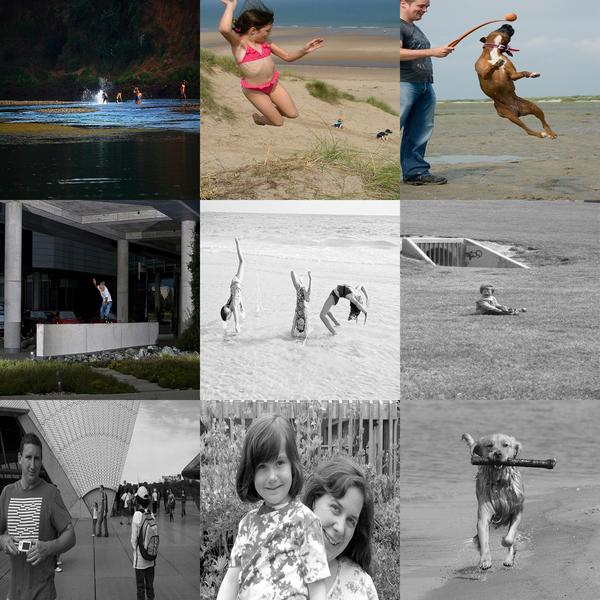
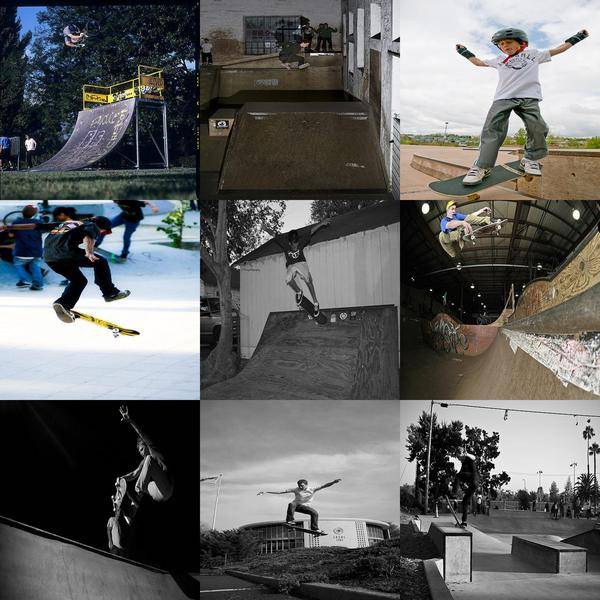
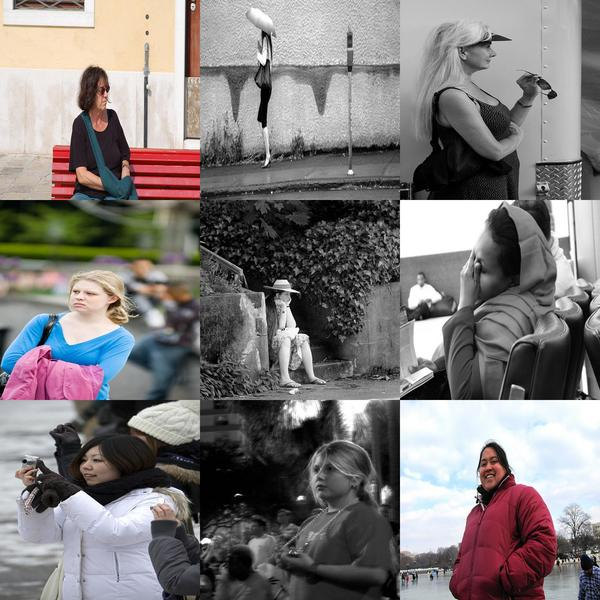
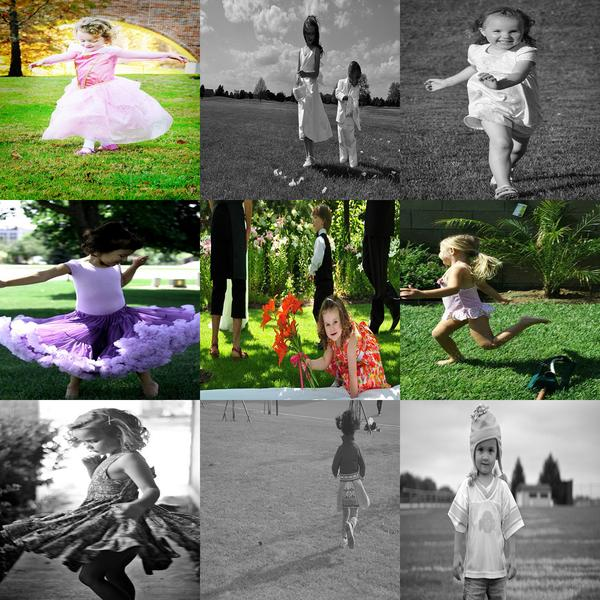

In [29]:
import base64
from io import BytesIO
from IPython.display import HTML
from PIL import Image

def get_thumbnail(im_path):
    image = Image.open(im_path)
    image.thumbnail((100, 100))  # Resize for display efficiency
    return image

def image_base64(im):
    if isinstance(im, str):
        im = get_thumbnail(im)
    with BytesIO() as buffer:
        im.save(buffer, 'jpeg')
        return base64.b64encode(buffer.getvalue()).decode()


def image_formatter(im):
    return f'<img src="data:image/jpeg;base64,{image_base64(im)}">'

# Extract dataframe
df = topic_model.get_topic_info().drop(["Representative_Docs", "Name"], axis=1)

df_sample = df.head(4)
# Visualize the images
HTML(df_sample.to_html(formatters={'Visual_Aspect': image_formatter}, escape=False))


## Images Only

Traditional topic modeling techniques can only be run on textual data, as is shown in the example above. However, there are plenty of cases where textual data is not available but images are. BERTopic allows topic modeling to be performed using only images as your input data.

To run BERTopic on images only, we first need to embed our images and then define a model that convert images to text. To do so, we are going to need some images. We will take the same images as the above but instead save them locally and pass the paths to the images instead. As mentioned before, this will make sure that we do not hold too many images in memory whilst only a small subset is needed:





In [1]:
import os
import glob
import zipfile
import numpy as np
import pandas as pd
from tqdm import tqdm
from sentence_transformers import util

# Flickr 8k images
img_folder = 'photos/'
caps_folder = 'captions/'
if not os.path.exists(img_folder) or len(os.listdir(img_folder)) == 0:
    os.makedirs(img_folder, exist_ok=True)

    if not os.path.exists('Flickr8k_Dataset.zip'):   #Download dataset if does not exist
        util.http_get('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flickr8k_Dataset.zip')
        util.http_get('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text.zip')

    for folder, file in [(img_folder, 'Flickr8k_Dataset.zip'), (caps_folder, 'Flickr8k_text.zip')]:
        with zipfile.ZipFile(file, 'r') as zf:
            for member in tqdm(zf.infolist(), desc='Extracting'):
                zf.extract(member, folder)
images = list(glob.glob('photos/Flicker8k_Dataset/*.jpg'))


  0%|          | 0.00/1.12G [00:00<?, ?B/s]

  0%|          | 0.00/2.34M [00:00<?, ?B/s]

Extracting: 100%|██████████| 10/10 [00:00<00:00, 633.92it/s]


Next, we can run our pipeline:

In [2]:
from bertopic.representation import KeyBERTInspired, VisualRepresentation
from bertopic.backend import MultiModalBackend

# Image embedding model
embedding_model = MultiModalBackend('clip-ViT-B-32', batch_size=32)

# Image to text representation model
representation_model = {
    "Visual_Aspect": VisualRepresentation(image_to_text_model="nlpconnect/vit-gpt2-image-captioning")
}


config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.49.0"
}

Config of the decoder: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'> is overwritten by shared decoder config: GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "decoder_start_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id"

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use mps:0


Using these models, we can run our pipeline:

In [3]:
from bertopic import BERTopic

# Train our model with images only
topic_model = BERTopic(embedding_model=embedding_model, representation_model=representation_model, min_topic_size=30)
topics, probs = topic_model.fit_transform(documents=None, images=images)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.
100%|██████████| 28/28 [00:00<00:00, 30.77it/s]


We can now access our image representations for each topic with topic_model.topic_aspects_["Visual_Aspect"]. If you want an overview of the topic images together with their textual representations in jupyter, you can run the following:

,Topic,Count,Representation,Visual_Aspect
0,-1,1165,"[while, air, the, frisbee, jumping, surfing, in, beach, woman, rock]",
1,0,1706,"[bench, sitting, people, woman, street, cell, phone, walking, her, talking]",
2,1,1293,"[grass, running, dog, grassy, field, through, across, frisbee, other, each]",
3,2,1181,"[boy, girl, little, young, holding, hugging, umbrella, pole, wooden, metal]",

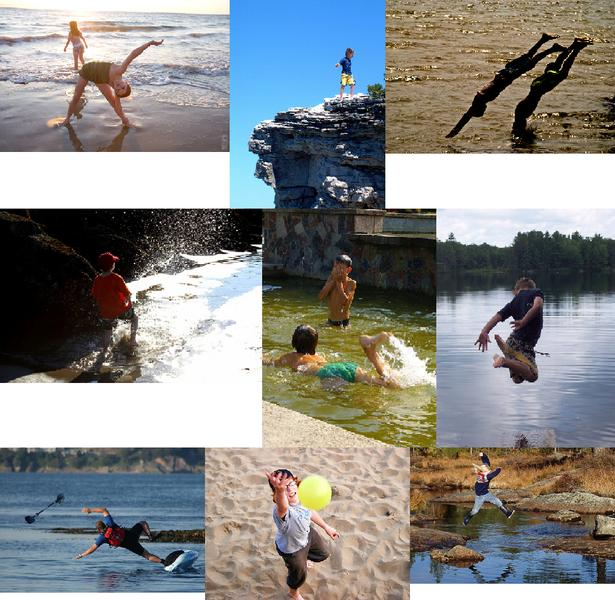
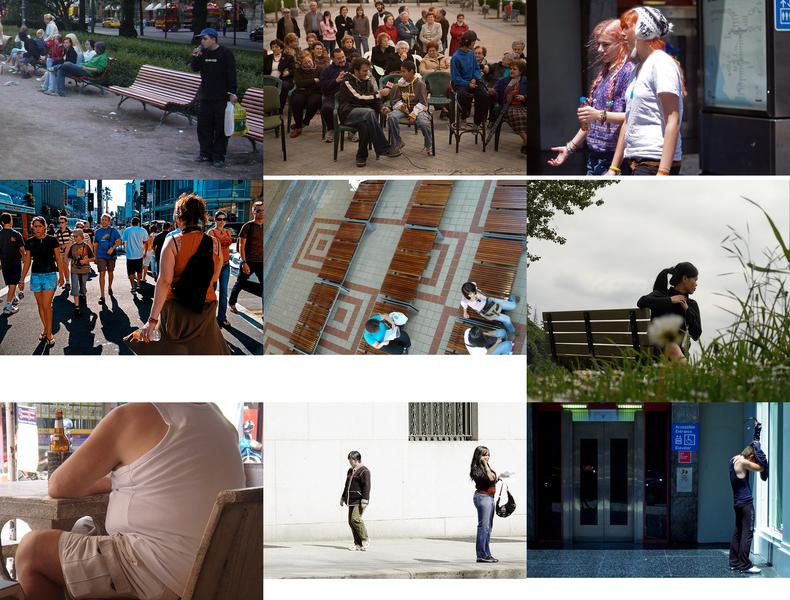
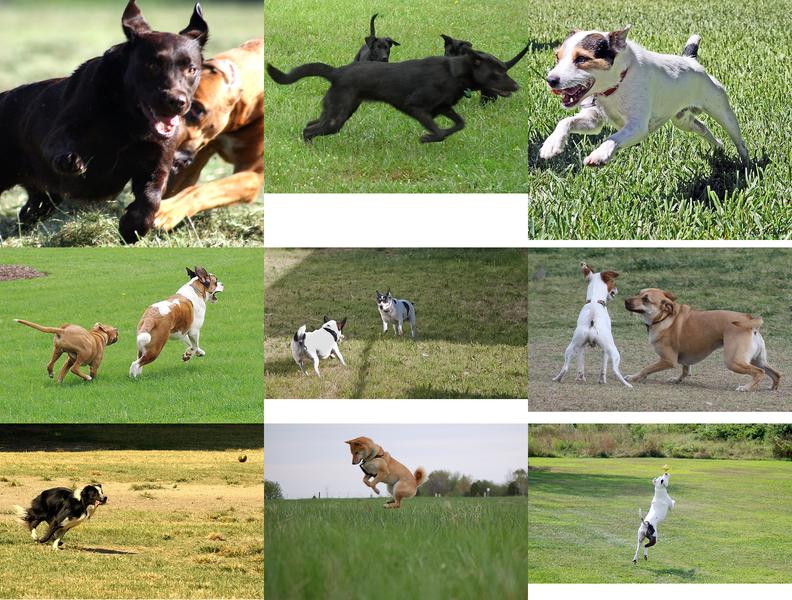
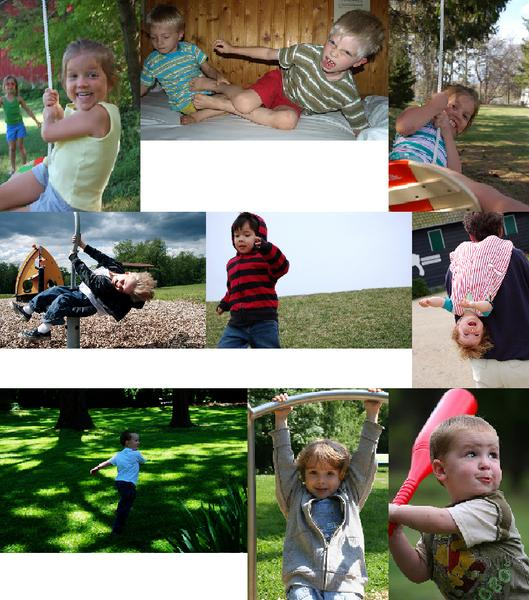

In [4]:
import base64
from io import BytesIO
from IPython.display import HTML

def image_base64(im):
    if isinstance(im, str):
        im = get_thumbnail(im)
    with BytesIO() as buffer:
        im.save(buffer, 'jpeg')
        return base64.b64encode(buffer.getvalue()).decode()


def image_formatter(im):
    return f'<img src="data:image/jpeg;base64,{image_base64(im)}">'

# Extract dataframe
df = topic_model.get_topic_info().drop(["Representative_Docs", "Name"], axis=1)

df_sample = df.head(4)
# Visualize the images
HTML(df_sample.to_html(formatters={'Visual_Aspect': image_formatter}, escape=False))

# [Online Topic Modeling](https://maartengr.github.io/BERTopic/getting_started/online/online.html)

Online topic modeling (sometimes called "incremental topic modeling") is the ability to learn incrementally from a mini-batch of instances. Essentially, it is a way to update your topic model with data on which it was not trained before. In Scikit-Learn, this technique is often modeled through a .partial_fit function, which is also used in BERTopic.

In BERTopic, there are three main goals for using this technique.

- To reduce the memory necessary for training a topic model.
- To continuously update the topic model as new data comes in.
- To continuously find new topics as new data comes in.

In BERTopic, online topic modeling can be a bit tricky as there are several steps involved in which online learning needs to be made available. To recap, BERTopic consists of the following 6 steps:

- Extract embeddings
- Reduce dimensionality
- Cluster reduced embeddings
- Tokenize topics
- Extract topic words
- (Optional) Fine-tune topic words

For some steps, an online variant is more important than others. Typically, in step 1 we use pre-trained language models that are in less need of continuous updates. This means that we can use an embedding model like Sentence-Transformers for extracting the embeddings and still use it in an online setting. Similarly, steps 5 and 6 do not necessarily need online variants since they are built upon step 4, tokenization. If that tokenization is by itself incremental, then so will steps 5 and 6.



![Online Training](online_topic_modeling.png)

This means that we will need online variants for steps 2 through 4. Steps 2 and 3, dimensionality reduction and clustering, can be modeled through the use of Scikit-Learn's .partial_fit function. In other words, it supports any algorithm that can be trained using .partial_fit since these algorithms can be trained incrementally. For example, incremental dimensionality reduction can be achieved using Scikit-Learn's IncrementalPCA and incremental clustering with MiniBatchKMeans.

Lastly, we need to develop an online variant for step 5, tokenization. In this step, a Bag-of-words representation is created through the CountVectorizer. However, as new data comes in, its vocabulary will need to be updated. For that purpose, bertopic.vectorizers.OnlineCountVectorizer was created that not only updates out-of-vocabulary words but also implements decay and cleaning functions to prevent the sparse bag-of-words matrix to become too large. Most notably, the decay parameter is a value between 0 and 1 to weigh the percentage of frequencies that the previous bag-of-words matrix should be reduced to. For example, a value of .1 will decrease the frequencies in the bag-of-words matrix by 10% at each iteration. This will make sure that recent data has more weight than previous iterations. Similarly, delete_min_df will remove certain words from its vocabulary if their frequency is lower than a set value. This ties together with the decay parameter as some words will decay over time if not used. For more information regarding the OnlineCountVectorizer, please see the vectorizers documentation.

## Example
Online topic modeling in BERTopic is rather straightforward. We first need to have our documents split into chunks such that we can train and update our topic model incrementally.



In [1]:
from sklearn.datasets import fetch_20newsgroups
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import IncrementalPCA
from bertopic.vectorizers import OnlineCountVectorizer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

# Prepare documents
all_docs = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))["data"]
doc_chunks = [all_docs[i:i+5000] for i in range(0, len(all_docs), 5000)]

# Define an embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Prepare sub-models
umap_model = IncrementalPCA(n_components=10)  # Increased for more variance
cluster_model = MiniBatchKMeans(n_clusters=10, random_state=0)  # Increased to allow more topics
vectorizer_model = OnlineCountVectorizer(stop_words="english", decay=0.01)

# Initialize BERTopic model
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    embedding_model=embedding_model,
    verbose=True
)

# Function to get topic descriptions
def get_topic_descriptions(model, topic_ids):
    topic_info = model.get_topic_info()
    descriptions = {}
    for topic_id in set(topic_ids):
        if topic_id != -1:
            topic_words = model.get_topic(topic_id)
            if topic_words:
                descriptions[topic_id] = " ".join([word for word, _ in topic_words[:5]])
    return descriptions

# Track topics incrementally
previous_topics = set()
previous_descriptions = {}
for i, docs in enumerate(doc_chunks, 1):
    print(f"\nProcessing Chunk {i} ({len(docs)} documents)")
    
    # Generate embeddings and convert to float64
    embeddings = embedding_model.encode(docs, show_progress_bar=False)
    embeddings = embeddings.astype(np.float64)
    
    # Partial fit with documents and embeddings
    topic_model.partial_fit(docs, embeddings)
    
    # Get current topics
    current_topics = set(topic_model.topics_)
    current_descriptions = get_topic_descriptions(topic_model, current_topics)
    
    # Analyze changes
    if i == 1:
        print(f"Initial Topics (Chunk {i}):")
        for topic_id in sorted(current_topics):
            if topic_id != -1:
                print(f"Topic {topic_id}: {current_descriptions.get(topic_id, 'No description')}")
    else:
        new_topics = current_topics - previous_topics
        print(f"Changes in Chunk {i}:")
        
        if new_topics:
            print("New Topics Added:")
            for topic_id in sorted(new_topics):
                if topic_id != -1:
                    print(f"Topic {topic_id}: {current_descriptions.get(topic_id, 'No description')}")
        else:
            print("No new topics added.")
        
        # Track changes in existing topics
        print("Updated Topics:")
        for topic_id in sorted(previous_topics & current_topics):
            old_desc = previous_descriptions.get(topic_id, "")
            new_desc = current_descriptions.get(topic_id, "")
            if old_desc != new_desc:
                print(f"Topic {topic_id} changed: {old_desc} -> {new_desc}")
    
    # Update previous state
    previous_topics = current_topics
    previous_descriptions = current_descriptions
    print(f"Total unique topics so far: {len(previous_topics)}")
    print(f"Cluster labels in this chunk: {sorted(current_topics)}")

# Final summary
print("\nFinal Topic Summary:")
final_topic_info = topic_model.get_topic_info()
final_topic_info[['Topic', 'Count', 'Name']]


Processing Chunk 1 (5000 documents)


2025-03-13 14:48:45,355 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-13 14:48:45,493 - BERTopic - Dimensionality - Completed ✓
2025-03-13 14:48:45,505 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-03-13 14:48:45,648 - BERTopic - Cluster - Completed ✓


Initial Topics (Chunk 1):
Topic 0: jpeg file image gif use
Topic 1: like just don time know
Topic 2: drive windows card scsi use
Topic 3: people armenian said armenians israel
Topic 4:     
Topic 5: game team 10 00 11
Topic 6: god jesus people christ say
Topic 7: 00 dos edu available mail
Topic 8: people government don president key
Topic 9: ax max edu space 00
Total unique topics so far: 10
Cluster labels in this chunk: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Processing Chunk 2 (5000 documents)


2025-03-13 14:49:03,592 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-13 14:49:03,752 - BERTopic - Dimensionality - Completed ✓
2025-03-13 14:49:03,755 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-13 14:49:03,819 - BERTopic - Cluster - Completed ✓


Changes in Chunk 2:
No new topics added.
Updated Topics:
Topic 0 changed: jpeg file image gif use -> ax max jpeg file window
Topic 1 changed: like just don time know -> ax max g9v just like
Topic 2 changed: drive windows card scsi use -> drive scsi card windows use
Topic 3 changed: people armenian said armenians israel -> people don just like armenian
Topic 4 changed:      -> hello hi   
Topic 5 changed: game team 10 00 11 -> game team 10 year play
Topic 6 changed: god jesus people christ say -> god jesus people bible say
Topic 7 changed: 00 dos edu available mail -> ax max 00 edu available
Topic 8 changed: people government don president key -> people government don right gun
Topic 9 changed: ax max edu space 00 -> ax edu space new entry
Total unique topics so far: 10
Cluster labels in this chunk: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Processing Chunk 3 (5000 documents)


2025-03-13 14:49:21,243 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-13 14:49:21,386 - BERTopic - Dimensionality - Completed ✓
2025-03-13 14:49:21,388 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-13 14:49:21,402 - BERTopic - Cluster - Completed ✓


Changes in Chunk 3:
No new topics added.
Updated Topics:
Topic 0 changed: ax max jpeg file window -> ax db image jpeg file
Topic 1 changed: ax max g9v just like -> ax myers ms car don
Topic 2 changed: drive scsi card windows use -> drive scsi card disk bus
Topic 3 changed: people don just like armenian -> don just like people hiv
Topic 4 changed: hello hi    -> hi hello   
Topic 5 changed: game team 10 year play -> game team games 55 season
Topic 6 changed: god jesus people bible say -> god people jesus think don
Topic 7 changed: ax max 00 edu available -> ax max b8f a86 g9v
Topic 8 changed: people government don right gun -> government people gun file law
Topic 9 changed: ax edu space new entry -> space edu data launch information
Total unique topics so far: 10
Cluster labels in this chunk: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Processing Chunk 4 (3846 documents)


2025-03-13 14:49:34,563 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-13 14:49:34,680 - BERTopic - Dimensionality - Completed ✓
2025-03-13 14:49:34,685 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-13 14:49:34,700 - BERTopic - Cluster - Completed ✓


Changes in Chunk 4:
No new topics added.
Updated Topics:
Topic 0 changed: ax db image jpeg file -> dos windows window image file
Topic 1 changed: ax myers ms car don -> car bike just like time
Topic 2 changed: drive scsi card disk bus -> card disk drive windows use
Topic 3 changed: don just like people hiv -> just kinsey don like people
Topic 4 changed: hi hello    -> hello hi   
Topic 5 changed: game team games 55 season -> 25 team game hockey games
Topic 6 changed: god people jesus think don -> god people jesus church jews
Topic 7 changed: ax max b8f a86 g9v -> 00 10 50 sale offer
Topic 8 changed: government people gun file law -> mr stephanopoulos people government don
Topic 9 changed: space edu data launch information -> edu space com wire use
Total unique topics so far: 10
Cluster labels in this chunk: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Final Topic Summary:


,Topic,Count,Name
0,0,1778,0_dos_windows_window_image
1,1,2043,1_car_bike_just_like
2,2,2324,2_card_disk_drive_windows
3,3,2180,3_just_kinsey_don_like
4,4,525,4_hello_hi__
5,5,1681,5_25_team_game_hockey
6,6,2325,6_god_people_jesus_church
7,7,1737,7_00_10_50_sale
8,8,2004,8_mr_stephanopoulos_people_government
9,9,2249,9_edu_space_com_wire


Why no new topics generated with incremental docs fitted(instead it update the existing topic cluster representation):
1. n_clusters=10 in MiniBatchKMeans:

- You’ve set MiniBatchKMeans(n_clusters=10), which means the clustering algorithm is limited to exactly 10 clusters (topics). This is a deliberate choice and aligns with your output showing 10 topics in Chunk 1. However, it also means that MiniBatchKMeans won’t create more than 10 topics, and subsequent chunks will only refine or reassign documents to these 10 clusters rather than adding new ones. This explains why no new topics are added after Chunk 1—there’s no capacity for more clusters beyond the initial 10.

2. Incremental Learning with partial_fit:

- MiniBatchKMeans’s partial_fit updates the existing centroids based on new data but doesn’t increase the number of clusters beyond n_clusters. If the initial 10 clusters from Chunk 1 adequately cover the variation in the 20 Newsgroups dataset, subsequent chunks will map to these same clusters, resulting in "No new topics added."

## River

To continuously find new topics as they come in, we can use the package river. It contains several clustering models that can create new clusters as new data comes in. To make sure we can use their models, we first need to create a class that has a .partial_fit function and the option to extract labels through .labels_:

In [ ]:
from river import stream, cluster

class River:
    def __init__(self, model):
        self.model = model

    def partial_fit(self, umap_embeddings):
        for umap_embedding, _ in stream.iter_array(umap_embeddings):
            self.model.learn_one(umap_embedding)

        labels = []
        for umap_embedding, _ in stream.iter_array(umap_embeddings):
            label = self.model.predict_one(umap_embedding)
            labels.append(label)

        self.labels_ = labels
        return self

Then, we can choose any river.cluster model that we are interested in and pass it to the River class before using it in BERTopic:

In [8]:
from sklearn.datasets import fetch_20newsgroups
import numpy as np
from river import stream, cluster
from sklearn.decomposition import IncrementalPCA
from bertopic.vectorizers import OnlineCountVectorizer, ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

# Custom River wrapper class
class River:
    def __init__(self, model):
        self.model = model

    def partial_fit(self, umap_embeddings):
        # Learn incrementally
        for umap_embedding, _ in stream.iter_array(umap_embeddings):
            self.model.learn_one(umap_embedding)
        
        # Predict labels for current batch
        labels = [self.model.predict_one(umap_embedding) for umap_embedding, _ in stream.iter_array(umap_embeddings)]
        self.labels_ = labels
        return self

# Prepare documents
all_docs = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))["data"]
doc_chunks = [all_docs[i:i+5000] for i in range(0, len(all_docs), 5000)]  # Further reduced to 500

# Define an embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Prepare sub-models
umap_model = IncrementalPCA(n_components=100)  # Increased to 100
cluster_model = River(cluster.DBSTREAM(clustering_threshold=0.3, fading_factor=0.1))  # More aggressive params
vectorizer_model = OnlineCountVectorizer(stop_words="english")
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)

# Initialize BERTopic model
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    embedding_model=embedding_model,
    verbose=True
)

# Function to get topic descriptions
def get_topic_descriptions(model, topic_ids):
    descriptions = {}
    for topic_id in set(topic_ids):
        if topic_id != -1:
            topic_words = model.get_topic(topic_id)
            if topic_words:
                descriptions[topic_id] = " ".join([word for word, _ in topic_words[:5]])
    return descriptions

# Track topics incrementally
previous_topics = set()
previous_descriptions = {}
for i, docs in enumerate(doc_chunks, 1):
    print(f"\nProcessing Chunk {i} ({len(docs)} documents)")
    
    embeddings = embedding_model.encode(docs, show_progress_bar=False).astype(np.float32)
    topic_model.partial_fit(docs, embeddings)
    
    current_topics = set(topic_model.topics_)
    current_descriptions = get_topic_descriptions(topic_model, current_topics)
    
    if i == 1:
        print(f"Initial Topics (Chunk {i}):")
        for topic_id in sorted(current_topics):
            if topic_id != -1:
                print(f"Topic {topic_id}: {current_descriptions.get(topic_id, 'No description')}")
    else:
        new_topics = current_topics - previous_topics
        print(f"Changes in Chunk {i}:")
        if new_topics:
            print("New Topics Added:")
            for topic_id in sorted(new_topics):
                if topic_id != -1:
                    print(f"Topic {topic_id}: {current_descriptions.get(topic_id, 'No description')}")
        else:
            print("No new topics added.")
        
        print("Updated Topics:")
        for topic_id in sorted(previous_topics & current_topics):
            old_desc = previous_descriptions.get(topic_id, "")
            new_desc = current_descriptions.get(topic_id, "")
            if old_desc != new_desc:
                print(f"Topic {topic_id} changed: {old_desc} -> {new_desc}")
    
    previous_topics = current_topics
    previous_descriptions = current_descriptions
    print(f"Total unique topics so far: {len(previous_topics) - (-1 in previous_topics)}")
    print(f"Cluster labels in this chunk: {sorted(current_topics)}")

# Final summary
print("\nFinal Topic Summary:")
final_topic_info = topic_model.get_topic_info()
final_topic_info[['Topic', 'Count', 'Name']]


Processing Chunk 1 (5000 documents)


2025-03-13 15:58:22,430 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-13 15:58:22,527 - BERTopic - Dimensionality - Completed ✓
2025-03-13 15:58:22,536 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-13 15:58:23,421 - BERTopic - Cluster - Completed ✓


Initial Topics (Chunk 1):
Topic 0: people like don just think
Topic 1: ax 00 edu file max
Total unique topics so far: 2
Cluster labels in this chunk: [0, 1]

Processing Chunk 2 (5000 documents)


2025-03-13 15:58:36,890 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-13 15:58:37,042 - BERTopic - Dimensionality - Completed ✓
2025-03-13 15:58:37,049 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-13 15:58:37,903 - BERTopic - Cluster - Completed ✓


Changes in Chunk 2:
No new topics added.
Updated Topics:
Topic 0 changed: people like don just think -> ax like people just don
Topic 1 changed: ax 00 edu file max -> ax don people like max
Total unique topics so far: 2
Cluster labels in this chunk: [0, 1]

Processing Chunk 3 (5000 documents)


2025-03-13 15:58:51,128 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-13 15:58:51,275 - BERTopic - Dimensionality - Completed ✓
2025-03-13 15:58:51,288 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-13 15:58:52,234 - BERTopic - Cluster - Completed ✓


Changes in Chunk 3:
No new topics added.
Updated Topics:
Topic 0 changed: ax like people just don -> ax max people like don
Topic 1 changed: ax don people like max -> ax don like people just
Total unique topics so far: 2
Cluster labels in this chunk: [0, 1]

Processing Chunk 4 (3846 documents)


2025-03-13 15:59:02,698 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-13 15:59:02,817 - BERTopic - Dimensionality - Completed ✓
2025-03-13 15:59:02,828 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-13 15:59:03,543 - BERTopic - Cluster - Completed ✓


Changes in Chunk 4:
No new topics added.
Updated Topics:
Topic 1 changed: ax don like people just -> ax don like just people
Total unique topics so far: 2
Cluster labels in this chunk: [0, 1]

Final Topic Summary:


,Topic,Count,Name
0,0,7861,0_ax_max_people_like
1,1,10985,1_ax_don_like_just


# [Merge Multiple Fitted Models](https://maartengr.github.io/BERTopic/getting_started/merge/merge.html)

After you have trained a new BERTopic model on your data, new data might still be coming in. Although you can use online BERTopic, you might prefer to use the default HDBSCAN and UMAP models since they do not support incremental learning out of the box.

Instead, we you can train a new BERTopic on incoming data and merge it with your base model to detect whether new topics have appeared in the unseen documents. This is a great way of detecting whether your new model contains information that was not previously found in your base topic model.

Similarly, you might want to train multiple BERTopic models using different sets of settings, even though they might all be using the same underlying embedding model. Merging these models would also allow for a single model that you can use throughout your use cases.

Lastly, this methods also allows for a degree of federated learning where each node trains a topic model that are aggregated in a central server.

## Example

To demonstrate merging different topic models with BERTopic, we use the ArXiv paper abstracts to see which topics they generally contain.

First, we train three separate models on different parts of the data:

In [1]:
from umap import UMAP
from bertopic import BERTopic
from datasets import load_dataset

dataset = load_dataset("CShorten/ML-ArXiv-Papers")["train"]

# Extract abstracts to train on and corresponding titles
abstracts_1 = dataset["abstract"][:5_000]
abstracts_2 = dataset["abstract"][5_000:10_000]
abstracts_3 = dataset["abstract"][10_000:15_000]

# Create topic models
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
topic_model_1 = BERTopic(umap_model=umap_model, min_topic_size=20).fit(abstracts_1)
topic_model_2 = BERTopic(umap_model=umap_model, min_topic_size=20).fit(abstracts_2)
topic_model_3 = BERTopic(umap_model=umap_model, min_topic_size=20).fit(abstracts_3)

README.md:   0%|          | 0.00/986 [00:00<?, ?B/s]

ML-Arxiv-Papers.csv:   0%|          | 0.00/147M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117592 [00:00<?, ? examples/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Then, we can combine all three models into one with .merge_models:

In [2]:
# Combine all models into one
merged_model = BERTopic.merge_models([topic_model_1, topic_model_2, topic_model_3])

When we inspect the first model, we can see it has 52 topics:

In [3]:
len(topic_model_1.get_topic_info())

51

Now, we inspect the merged model, we can see it has 57 topics:

In [5]:
len(merged_model.get_topic_info())

58

It seems that by merging these three models, there were 7 undiscovered topics that we could add to the very first model.

We can check the newly added topics in the merged_model by simply looking at the 7 latest topics that were added. The order of topics from topic_model_1 remains the same. All new topics are simply added on top of them.

Let's inspect them:


In [6]:
merged_model.get_topic_info().tail(5)

,Topic,Count,Name,Representation,Representative_Docs
53,52,47,52_music_musical_audio_chord,"[music, musical, audio, chord, song, to, and, ...",NaN
54,53,32,53_fairness_discrimination_fair_groups,"[fairness, discrimination, fair, groups, prote...",NaN
55,54,30,54_traffic_driver_prediction_flow,"[traffic, driver, prediction, flow, trajectory...",NaN
56,55,26,55_activity_recognition_sensor_falls,"[activity, recognition, sensor, falls, wearabl...",NaN
57,56,22,56_spiking_neurons_networks_learning,"[spiking, neurons, networks, learning, neural,...",NaN


It seems that topics about activity, music, fairness, traffic, and spiking networks were added to the base topic model! Two things that you might have noticed. First, the representative documents were not added to the model. This is because of privacy reasons, you might want to combine models that were trained on different stations which would allow for a degree of federated learning. Second, the names of the new topics contain topic ids that refer to one of the old models. They were purposefully left this way so that the user can identify which topics were newly added which you could inspect in the original models.

## min_similarity

The way the models are merged is through comparison of their topic embeddings. If topics between models are similar enough, then they will be regarded as the same topics and the topic of the first model in the list will be chosen. However, if topics between models are dissimilar enough, then the topic of the latter model will be added to the former.

This (dis)similarity is can be tweaked using the min_similarity parameter. Increasing this value will increase the chance of adding new topics. In contrast, decreasing this value will make it more strict and threfore decrease the chance of adding new topics. The value is set to 0.7 by default, so let's see what happens if we were to increase this value to `0.9``:

In [7]:
# Combine all models into one
merged_model = BERTopic.merge_models([topic_model_1, topic_model_2, topic_model_3], min_similarity=0.9)

When we inspect the number of topics in our new model, we can see that they have increased quite a bit:

In [8]:
len(merged_model.get_topic_info())

94

This demonstrates the influence of min_similarity on the number of new topics that are added to the base model.

# (Semi)- Supervised

## [Semi-supervised Topic Modeling](https://maartengr.github.io/BERTopic/getting_started/semisupervised/semisupervised.html)

In BERTopic, you have several options to nudge the creation of topics toward certain pre-specified topics. Here, we will be looking at semi-supervised topic modeling with BERTopic.

Semi-supervised modeling allows us to steer the dimensionality reduction of the embeddings into a space that closely follows any labels you might already have.

In other words, we use a semi-supervised UMAP instance to reduce the dimensionality of embeddings before clustering the documents with HDBSCAN.

First, let us prepare the data needed for our topic model:

In [9]:
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))
docs = data["data"]
categories = data["target"]
category_names = data["target_names"]

We are using the popular 20 Newsgroups dataset which contains roughly 18000 newsgroups posts that each is assigned to one of 20 categories. Using this dataset we can try to extract its corresponding topic model whilst taking its underlying categories into account. These categories are here the variable targets.

Each document can be put into one of the following categories:

In [10]:
category_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

To perform this semi-supervised approach, we can take in some pre-defined topics and simply pass those to the y parameter when fitting BERTopic. These labels can be pre-defined topics or simply documents that you feel belong together regardless of their content. BERTopic will nudge the creation of topics toward these categories using the pre-defined labels.

To perform supervised topic modeling, we simply use all categories:

In [11]:
topic_model = BERTopic(verbose=True).fit(docs, y=categories)

2025-03-14 14:41:58,264 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

2025-03-14 14:43:02,255 - BERTopic - Embedding - Completed ✓
2025-03-14 14:43:02,256 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-14 14:43:07,672 - BERTopic - Dimensionality - Completed ✓
2025-03-14 14:43:07,674 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current p

In [13]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5519,-1_and_the_to_for,"[and, the, to, for, is, of, in, it, you, on]",[\n#Rick Anderson replied to my letter with......
1,0,935,0_space_launch_nasa_orbit,"[space, launch, nasa, orbit, shuttle, mission,...",[THE ELECTRONIC JOURNAL OF\n ...
2,1,908,1_game_he_baseball_year,"[game, he, baseball, year, team, games, player...",[So far Simmons looks like a total idiot.\n\n\...
3,2,865,2_gun_guns_firearms_fbi,"[gun, guns, firearms, fbi, weapons, fire, they...","[\n Mr. Parsli, I have to take exception..."
4,3,584,3_key_clipper_chip_encryption,"[key, clipper, chip, encryption, keys, escrow,...","[April 16, 1993\n\nINITIAL EFF ANALYSIS OF CLI..."
...,...,...,...,...,...
239,238,11,238_bobbeviceicotekcom_beauchaine_sank_bronx,"[bobbeviceicotekcom, beauchaine, sank, bronx, ...",[\n Do I smell .sig material here?\n\n\n/\/\/...
240,239,11,239_risc_instruction_cisc_nextstep,"[risc, instruction, cisc, nextstep, intel, ins...","[Dear friend,\n The RISC means ""reduced instr..."
241,240,11,240_faq_ooopsthat_j3davidstudentbusinessuwoca_...,"[faq, ooopsthat, j3davidstudentbusinessuwoca, ...","[ \n \n As far as I know, there is no F..."
242,241,10,241_bible_christians_zeus_phamphlet,"[bible, christians, zeus, phamphlet, you, god,...",[/(Frank DeCenso)\n/>\n/>I need to prioritize ...


The topic model will be much more attuned to the categories that were defined previously. However, this does not mean that only topics for these categories will be found. BERTopic is likely to find more specific topics in those you have already defined. This allows you to discover previously unknown topics!

### Partial labels

At times, you might only have labels for a subset of documents. Fortunately, we can still use those labels to at least nudge the documents for which those labels exist. The documents for which we do not have labels are assigned a -1. For this example, imagine we only have the labels of categories that are related to computers and we want to create a topic model using semi-supervised modeling:

In [14]:
labels_to_add = ['comp.graphics', 'comp.os.ms-windows.misc',
              'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware',
              'comp.windows.x',]
indices = [category_names.index(label) for label in labels_to_add]
y = [label if label in indices else -1 for label in categories]


In [20]:
print(set(categories))

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19}


In [21]:
print(set(y))

{1, 2, 3, 4, 5, -1}


The y variable contains many -1 values since we do not know all the categories.

Next, we use those newly constructed labels to again BERTopic semi-supervised:

In [22]:
topic_model = BERTopic(verbose=True).fit(docs, y=y)

2025-03-14 16:39:08,073 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

2025-03-14 16:40:00,118 - BERTopic - Embedding - Completed ✓
2025-03-14 16:40:00,119 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-14 16:40:04,447 - BERTopic - Dimensionality - Completed ✓
2025-03-14 16:40:04,449 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current p

And that is it! By defining certain classes for our documents, we can steer the topic modeling towards modeling the pre-defined categories.

In [23]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,6114,-1_to_of_the_and,"[to, of, the, and, for, is, you, in, that, it]",[[This is a co-authored report from two of us ...
1,0,1828,0_game_team_games_he,"[game, team, games, he, players, season, hocke...","[Apparently, Part 2 (defensemen numbered 2 thr..."
2,1,874,1_window_server_motif_widget,"[window, server, motif, widget, xterm, display...",[Archive-name: x-faq/part4\nLast-modified: 199...
3,2,602,2_key_clipper_chip_encryption,"[key, clipper, chip, encryption, keys, escrow,...","[\nInteresting. Tell us, what happens if I we..."
4,3,527,3_ites_cheek_yep_huh,"[ites, cheek, yep, huh, ken, art, why, tell, e...","[\n\t\t\t\t\tart\n, \nHuh?, ites:]"
...,...,...,...,...,...
204,203,10,203_s414_bill_bills_brady,"[s414, bill, bills, brady, senate, ab, sb, hou...",[I'd appreciate any help anyone could give me ...
205,204,10,204_religion_motivated_religious_wars,"[religion, motivated, religious, wars, history...",[\n: Regardless of people's hidden motivations...
206,205,10,205_taste_miracle_sweet_substances,"[taste, miracle, sweet, substances, berries, m...",[:In article <1993Apr22.205341.172965@locus.co...
207,206,10,206_law_jesus_sabbath_worship,"[law, jesus, sabbath, worship, god, heaven, ph...",[\nI will clarify my earlier quote. God's law...


## Supervised Topic Modeling

Although topic modeling is typically done by discovering topics in an unsupervised manner, there might be times when you already have a bunch of clusters or classes from which you want to model the topics. For example, the often used 20 NewsGroups dataset is already split up into 20 classes. Similarly, you might already have created some labels yourself through packages like human-learn, bulk, thisnotthat or something entirely different.

Instead of using BERTopic to discover previously unknown topics, we are now going to manually pass them to BERTopic and try to learn the relationship between those topics and the input documents.

In other words, we are going to be performing classification instead!

We can view this as a supervised topic modeling approach. Instead of using a clustering algorithm, we are going to be using a classification algorithm instead.

Generally, we have the following pipeline:

Instead, we are now going to skip over the dimensionality reduction step and replace the clustering step with a classification model:


In other words, we can pass our labels to BERTopic and it will not only learn how to predict labels for new instances, but it also transforms those labels into topics by running the c-TF-IDF representations on the set of documents within each label. This process allows us to model the topics themselves and similarly gives us the option to use everything BERTopic has to offer.

To do so, we need to skip over the dimensionality reduction step and replace the clustering step with a classification algorithm. We can use the documents and labels from the 20 NewsGroups dataset to create topics from those 20 labels:

In [24]:
from sklearn.datasets import fetch_20newsgroups

# Get labeled data
data = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))
docs = data['data']
y = data['target']


Then, we make sure to create empty instances of the dimensionality reduction and clustering steps. We pass those to BERTopic to simply skip over them and go to the topic representation process:

In [25]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.dimensionality import BaseDimensionalityReduction
from sklearn.linear_model import LogisticRegression

# Get labeled data
data = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))
docs = data['data']
y = data['target']

# Skip over dimensionality reduction, replace cluster model with classifier,
# and reduce frequent words while we are at it.
empty_dimensionality_model = BaseDimensionalityReduction()
clf = LogisticRegression()
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

# Create a fully supervised BERTopic instance
topic_model= BERTopic(
        umap_model=empty_dimensionality_model,
        hdbscan_model=clf,
        ctfidf_model=ctfidf_model
)
topics, probs = topic_model.fit_transform(docs, y=y)


In [26]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,999,0_game_hockey_team_25,"[game, hockey, team, 25, season, 550, nhl, pla...",[NHL RESULTS FOR GAMES PLAYED 4/15/93.\n\n----...
1,1,997,1_god_church_jesus_christ,"[god, church, jesus, christ, we, not, he, his,...",[From Bit.listserv.christia\n\nZane writes...\...
2,2,996,2_bike_dod_ride_bikes,"[bike, dod, ride, bikes, riding, motorcycle, m...",[ I need some advice on having someone ride ...
3,3,994,3_baseball_game_he_year,"[baseball, game, he, year, hit, players, games...",[I thought I'd post my predicted standings sin...
4,4,991,4_key_encryption_db_clipper,"[key, encryption, db, clipper, chip, keys, pri...",[This document is in the anonymous ftp directo...
5,5,990,5_car_cars_engine_ford,"[car, cars, engine, ford, oil, dealer, my, it,...",[It's been a while since I've reviewed a car b...
6,6,990,6_medical_patients_cancer_disease,"[medical, patients, cancer, disease, health, v...",[------------- cut here -----------------\n\n\...
7,7,988,7_window_server_widget_motif,"[window, server, widget, motif, file, entry, x...",[Archive-name: Intel-Unix-X-faq\nLast-modified...
8,8,987,8_space_launch_nasa_orbit,"[space, launch, nasa, orbit, shuttle, spacecra...",[Archive-name: space/acronyms\nEdition: 8\n\nA...
9,9,985,9_maxaxaxaxaxaxaxaxaxaxaxaxaxaxax_windows_dos_...,"[maxaxaxaxaxaxaxaxaxaxaxaxaxaxax, windows, dos...","[I don't know much about computers, so please ..."


We can see several interesting topics appearing here. They seem to relate to the 20 classes we had as input. Now, let's map those topics to our original classes to view their relationship:

In [27]:
# Map input `y` to topics
mappings = topic_model.topic_mapper_.get_mappings()
mappings = {value: data["target_names"][key] for key, value in mappings.items()}

# Assign original classes to our topics
df = topic_model.get_topic_info()
df["Class"] = df.Topic.map(mappings)
df


,Topic,Count,Name,Representation,Representative_Docs,Class
0,0,999,0_game_hockey_team_25,"[game, hockey, team, 25, season, 550, nhl, pla...",[NHL RESULTS FOR GAMES PLAYED 4/15/93.\n\n----...,rec.sport.hockey
1,1,997,1_god_church_jesus_christ,"[god, church, jesus, christ, we, not, he, his,...",[From Bit.listserv.christia\n\nZane writes...\...,soc.religion.christian
2,2,996,2_bike_dod_ride_bikes,"[bike, dod, ride, bikes, riding, motorcycle, m...",[ I need some advice on having someone ride ...,rec.motorcycles
3,3,994,3_baseball_game_he_year,"[baseball, game, he, year, hit, players, games...",[I thought I'd post my predicted standings sin...,rec.sport.baseball
4,4,991,4_key_encryption_db_clipper,"[key, encryption, db, clipper, chip, keys, pri...",[This document is in the anonymous ftp directo...,sci.crypt
5,5,990,5_car_cars_engine_ford,"[car, cars, engine, ford, oil, dealer, my, it,...",[It's been a while since I've reviewed a car b...,rec.autos
6,6,990,6_medical_patients_cancer_disease,"[medical, patients, cancer, disease, health, v...",[------------- cut here -----------------\n\n\...,sci.med
7,7,988,7_window_server_widget_motif,"[window, server, widget, motif, file, entry, x...",[Archive-name: Intel-Unix-X-faq\nLast-modified...,comp.windows.x
8,8,987,8_space_launch_nasa_orbit,"[space, launch, nasa, orbit, shuttle, spacecra...",[Archive-name: space/acronyms\nEdition: 8\n\nA...,sci.space
9,9,985,9_maxaxaxaxaxaxaxaxaxaxaxaxaxaxax_windows_dos_...,"[maxaxaxaxaxaxaxaxaxaxaxaxaxaxax, windows, dos...","[I don't know much about computers, so please ...",comp.os.ms-windows.misc


We can see that the c-TF-IDF representations extract the words that give a good representation of our input classes. This is all done directly from the labeling. A welcome side-effect is that we now have a classification algorithm that allows us to predict the topics of unseen data:

In [31]:
# Predict topic for a new document and fix the error
new_doc = "this is a document about cars"
topic, _ = topic_model.transform(new_doc)  # Returns a list, e.g., [7]
topic_id = topic[0]  # Extract the integer topic ID, e.g., 7
topic_words = topic_model.get_topic(topic_id)  # Now works with an integer
print(f"Predicted Topic ID: {topic_id}")
print(f"Topic Words: {topic_words}")
print(f"Predicted Class: {mappings.get(topic_id, 'Unknown')}")

Predicted Topic ID: 5
Topic Words: [('car', 0.4335337352973449), ('cars', 0.3244268566005988), ('engine', 0.27676448763139894), ('ford', 0.24369429891593442), ('oil', 0.2269662000344348), ('dealer', 0.22614466309960873), ('my', 0.21565594466251384), ('it', 0.20688940802563946), ('tires', 0.2043356021185632), ('brake', 0.2033505642268938)]
Predicted Class: rec.autos


In [29]:
topic

[5]

Moreover, we can still perform BERTopic-specific features like dynamic topic modeling, topics per class, hierarchical topic modeling, modeling topic distributions, etc.


## Manual Topic Modeling

Although topic modeling is typically done by discovering topics in an unsupervised manner, there might be times when you already have a bunch of clusters or classes from which you want to model the topics. For example, the often used 20 NewsGroups dataset is already split up into 20 classes. Here, we might want to see how we can transform those 20 classes into 20 topics. Instead of using BERTopic to discover previously unknown topics, we are now going to manually pass them to BERTopic without actually learning them.

We can view this as a manual topic modeling approach. There is no underlying algorithm for detecting these topics since you already have done that before. Whether that is simply because they are already available, like with the 20 NewsGroups dataset, or maybe because you have created clusters of documents before using packages like human-learn, bulk, thisnotthat or something entirely different.

In other words, we can pass our labels to BERTopic and it will try to transform those labels into topics by running the c-TF-IDF representations on the set of documents within each label. This process allows us to model the topics themselves and similarly gives us the option to use everything BERTopic has to offer.

To do so, we need to skip over the dimensionality reduction and clustering steps since we already know the labels for our documents. We can use the documents and labels from the 20 NewsGroups dataset to create topics from those 20 labels:

In [32]:
from sklearn.datasets import fetch_20newsgroups

# Get labeled data
data = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))
docs = data['data']
y = data['target']


Then, we make sure to create empty instances of the dimensionality reduction and clustering steps. We pass those to BERTopic to simply skip over them and go to the topic representation process:

In [33]:
from bertopic import BERTopic
from bertopic.backend import BaseEmbedder
from bertopic.cluster import BaseCluster
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.dimensionality import BaseDimensionalityReduction

# Prepare our empty sub-models and reduce frequent words while we are at it.
empty_embedding_model = BaseEmbedder()
empty_dimensionality_model = BaseDimensionalityReduction()
empty_cluster_model = BaseCluster()
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

# Fit BERTopic without actually performing any clustering
topic_model= BERTopic(
        embedding_model=empty_embedding_model,
        umap_model=empty_dimensionality_model,
        hdbscan_model=empty_cluster_model,
        ctfidf_model=ctfidf_model
)
topics, probs = topic_model.fit_transform(docs, y=y)


Let's take a look at a few topics that we get out of training this way by running

In [34]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,999,0_game_hockey_team_25,"[game, hockey, team, 25, season, 55, nhl, play...",[NHL RESULTS FOR GAMES PLAYED 4/15/93.\n\n----...
1,1,997,1_god_church_jesus_christ,"[god, church, jesus, christ, not, that, his, w...",[From Bit.listserv.christia\n\nZane writes...\...
2,2,996,2_bike_dod_ride_bikes,"[bike, dod, ride, bikes, riding, motorcycle, m...",[ I need some advice on having someone ride ...
3,3,994,3_he_baseball_game_year,"[he, baseball, game, year, 03, hit, team, game...",[Since I was the one responsible for these div...
4,4,991,4_key_encryption_clipper_db,"[key, encryption, clipper, db, chip, privacy, ...",[Archive-name: ripem/faq\nLast-update: 31 Mar ...
5,5,990,5_car_cars_engine_ford,"[car, cars, engine, ford, oil, dealer, my, it,...",[It's been a while since I've reviewed a car b...
6,6,990,6_medical_cancer_patients_disease,"[medical, cancer, patients, disease, health, h...",[------------- cut here -----------------\n\n\...
7,7,988,7_window_server_motif_widget,"[window, server, motif, widget, file, x11, ent...",[Archive-name: Intel-Unix-X-faq\nLast-modified...
8,8,987,8_space_nasa_launch_orbit,"[space, nasa, launch, orbit, shuttle, earth, m...",[Archive-name: space/data\nLast-modified: $Dat...
9,9,985,9_ax_max_g9v_b8f,"[ax, max, g9v, b8f, a86, pl, 145, windows, 1d9...",[MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'...


We can see several interesting topics appearing here. They seem to relate to the 20 classes we had as input. Now, let's map those topics to our original classes to view their relationship:



In [35]:
# Map input `y` to topics
mappings = topic_model.topic_mapper_.get_mappings()
mappings = {value: data["target_names"][key] for key, value in mappings.items()}

# Assign original classes to our topics
df = topic_model.get_topic_info()
df["Class"] = df.Topic.map(mappings)
df


,Topic,Count,Name,Representation,Representative_Docs,Class
0,0,999,0_game_hockey_team_25,"[game, hockey, team, 25, season, 55, nhl, play...",[NHL RESULTS FOR GAMES PLAYED 4/15/93.\n\n----...,rec.sport.hockey
1,1,997,1_god_church_jesus_christ,"[god, church, jesus, christ, not, that, his, w...",[From Bit.listserv.christia\n\nZane writes...\...,soc.religion.christian
2,2,996,2_bike_dod_ride_bikes,"[bike, dod, ride, bikes, riding, motorcycle, m...",[ I need some advice on having someone ride ...,rec.motorcycles
3,3,994,3_he_baseball_game_year,"[he, baseball, game, year, 03, hit, team, game...",[Since I was the one responsible for these div...,rec.sport.baseball
4,4,991,4_key_encryption_clipper_db,"[key, encryption, clipper, db, chip, privacy, ...",[Archive-name: ripem/faq\nLast-update: 31 Mar ...,sci.crypt
5,5,990,5_car_cars_engine_ford,"[car, cars, engine, ford, oil, dealer, my, it,...",[It's been a while since I've reviewed a car b...,rec.autos
6,6,990,6_medical_cancer_patients_disease,"[medical, cancer, patients, disease, health, h...",[------------- cut here -----------------\n\n\...,sci.med
7,7,988,7_window_server_motif_widget,"[window, server, motif, widget, file, x11, ent...",[Archive-name: Intel-Unix-X-faq\nLast-modified...,comp.windows.x
8,8,987,8_space_nasa_launch_orbit,"[space, nasa, launch, orbit, shuttle, earth, m...",[Archive-name: space/data\nLast-modified: $Dat...,sci.space
9,9,985,9_ax_max_g9v_b8f,"[ax, max, g9v, b8f, a86, pl, 145, windows, 1d9...",[MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'...,comp.os.ms-windows.misc


We can see that the c-TF-IDF representations nicely extract the words that give a nice representation of our input classes. This is all done without actually embedding and clustering the data.

As a result, the entire "training" process only takes a couple of seconds. Moreover, we can still perform BERTopic-specific features like dynamic topic modeling, topics per class, hierarchical topic modeling, modeling topic distributions, etc.

## Guided Topic Modeling

Guided Topic Modeling or Seeded Topic Modeling is a collection of techniques that guides the topic modeling approach by setting several seed topics to which the model will converge to. These techniques allow the user to set a predefined number of topic representations that are sure to be in documents. For example, take an IT business that has a ticket system for the software their clients use. Those tickets may typically contain information about a specific bug regarding login issues that the IT business is aware of.

To model that bug, we can create a seed topic representation containing the words bug, login, password, and username. By defining those words, a Guided Topic Modeling approach will try to converge at least one topic to those words.

Guided BERTopic has two main steps:

First, we create embeddings for each seeded topic by joining them and passing them through the document embedder. These embeddings will be compared with the existing document embeddings through cosine similarity and assigned a label. If the document is most similar to a seeded topic, then it will get that topic's label. If it is most similar to the average document embedding, it will get the -1 label. These labels are then passed through UMAP to create a semi-supervised approach that should nudge the topic creation to the seeded topics.

Second, we take all words in seed_topic_list and assign them a multiplier larger than 1. Those multipliers will be used to increase the IDF values of the words across all topics thereby increasing the likelihood that a seeded topic word will appear in a topic. This does, however, also increase the chance of an irrelevant topic having unrelated words. In practice, this should not be an issue since the IDF value is likely to remain low regardless of the multiplier. The multiplier is now a fixed value but may change to something more elegant, like taking the distribution of IDF values and its position into account when defining the multiplier.

### Example

To demonstrate Guided BERTopic, we use the 20 Newsgroups dataset as our example. We have frequently used this dataset in BERTopic examples and we sometimes see a topic generated about health with words such as drug and cancer being important. However, due to the stochastic nature of UMAP, this topic is not always found.

In order to guide BERTopic to that topic, we create a seed topic list that we pass through our model. However, there may be several other topics that we know should be in the documents. Let's also initialize those:

In [36]:
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups

docs = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))["data"]

seed_topic_list = [["drug", "cancer", "drugs", "doctor"],
                   ["windows", "drive", "dos", "file"],
                   ["space", "launch", "orbit", "lunar"]]

topic_model = BERTopic(seed_topic_list=seed_topic_list)
topics, probs = topic_model.fit_transform(docs)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [ ]:
# it is not neccessary to have all four words appear in the Name column
df_info = topic_model.get_topic_info()
df_info[df_info.Name.str.contains("dos")]

,Topic,Count,Name,Representation,Representative_Docs
54,53,48,53_dos_mbytes_windows_tcpip,"[dos, mbytes, windows, tcpip, ms, mouse, ftp, ...",[Bristol Technology announces the availability...
123,122,22,122_windows_dos_network_os2,"[windows, dos, network, os2, files, unix, loca...",[\nThese are perfectly valid points and I agre...
184,183,13,183_mouse_driver_windows_dos,"[mouse, driver, windows, dos, sensitivity, 31,...","['lo all,\n\n I am writting a program that ch..."


As you can see above, the seed_topic_list contains a list of topic representations. By defining the above topics BERTopic is more likely to model the defined seeded topics. However, BERTopic is merely nudged towards creating those topics. In practice, if the seeded topics do not exist or might be divided into smaller topics, then they will not be modeled. Thus, seed topics need to be accurate to accurately converge towards them.

## Zero-shot Topic Modeling
Zero-shot Topic Modeling is a technique that allows you to find topics in large amounts of documents that were predefined. When faced with many documents, you often have an idea of which topics will definitely be in there. Whether that is a result of simply knowing your data or if a domain expert is involved in defining those topics.

This method allows you to not only find those specific topics but also create new topics for documents that would not fit with your predefined topics. This allows for extensive flexibility as there are three scenario's to explore:

First, both zero-shot topics and clustered topics were detected. This means that some documents would fit with the predefined topics where others would not. For the latter, new topics were found.
Second, only zero-shot topics were detected. Here, we would not need to find additional topics since all original documents were assigned to one of the predefined topics.
Third, no zero-shot topics were detected. This means that none of the documents would fit with the predefined topics and a regular BERTopic would be run.

This method works as follows. First, we create a number of labels for our predefined topics and embed them using any embedding model. Then, we compare the embeddings of the documents with the predefined labels using cosine similarity. If they pass a user-defined threshold, the zero-shot topic is assigned to a document. If it does not, then that document, along with others, will follow the regular BERTopic pipeline and attempt to find clusters that do not fit with the zero-shot topics.

### Example

In order to use zero-shot BERTopic, we create a list of topics that we want to assign to our documents. However, there may be several other topics that we know should be in the documents. The dataset that we use is small subset of ArXiv papers. We know the data and believe there to be at least the following topics: clustering, topic modeling, and large language models. However, we are not sure whether other topics exist and want to explore those.

Zero-shot BERTopic needs two parameters: * zeroshot_topic_list - The names of the topics to assign documents to. Making sure this is as descriptive as possible helps improve the assignment since they are based on cosine similarities between embeddings. * zeroshot_min_similarity - The minimum cosine similarity needed to match a document to a document. It is a value between 0 and 1.

Using this feature is straightforward:

In [43]:
from datasets import load_dataset

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired

# We select a subsample of 5000 abstracts from ArXiv
dataset = load_dataset("CShorten/ML-ArXiv-Papers")["train"]
docs = dataset["abstract"][:5_000]

# We define a number of topics that we know are in the documents
zeroshot_topic_list = ["Clustering", "Topic Modeling", "Large Language Models"]

# We fit our model using the zero-shot topics
# and we define a minimum similarity. For each document,
# if the similarity does not exceed that value, it will be used
# for clustering instead.
topic_model = BERTopic(
    embedding_model="thenlper/gte-small", 
    min_topic_size=15,
    zeroshot_topic_list=zeroshot_topic_list,
    zeroshot_min_similarity=.85,
    representation_model=KeyBERTInspired()
)
topics, _ = topic_model.fit_transform(docs)


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/68.1k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [44]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1495,-1_prediction_regression_classifier_sparse,"[prediction, regression, classifier, sparse, k...",[ We study sequential prediction of real-valu...
1,0,281,Clustering,"[clustering, clusterings, clusters, cluster, a...",[ Recent spectral clustering methods are a pr...
2,1,82,Topic Modeling,"[topic, topics, inference, corpora, modeling, ...",[ Document clustering and topic modeling are ...
3,2,34,Large Language Models,"[language, embeddings, languages, neural, repr...","[ In spite of their superior performance, neu..."
4,3,24,3_quantum_algorithms_algorithm_superposition,"[quantum, algorithms, algorithm, superposition...","[ The key approaches for machine learning, es..."
...,...,...,...,...,...
61,60,82,60_matrices_matrix_rank_algorithms,"[matrices, matrix, rank, algorithms, approxima...",[ We consider the problem of reconstructing a...
62,61,25,61_classifiers_classifier_ensemblesvm_classifi...,"[classifiers, classifier, ensemblesvm, classif...",[ Ensemble classification is an emerging appr...
63,62,53,62_boosting_boost_classifiers_classifier,"[boosting, boost, classifiers, classifier, cla...",[ Abc-boost is a new line of boosting algorit...
64,63,84,63_sparse_regularization_lasso_regularized,"[sparse, regularization, lasso, regularized, s...",[ We present a data dependent generalization ...


The zeroshot_min_similarity parameter controls how many of the documents are assigned to the predefined zero-shot topics. Lower this value and you will have more documents assigned to zero-shot topics and fewer documents will be clustered. Increase this value you will have fewer documents assigned to zero-shot topics and more documents will be clustered.



# Topic Distributions

BERTopic approaches topic modeling as a cluster task and attempts to cluster semantically similar documents to extract common topics. A disadvantage of using such a method is that each document is assigned to a single cluster and therefore also a single topic. In practice, documents may contain a mixture of topics. This can be accounted for by splitting up the documents into sentences and feeding those to BERTopic.

Another option is to use a cluster model that can perform soft clustering, like HDBSCAN. As BERTopic focuses on modularity, we may still want to model that mixture of topics even when we are using a hard-clustering model, like k-Means without the need to split up our documents. This is where .approximate_distribution comes in!

To perform this approximation, each document is split into tokens according to the provided tokenizer in the CountVectorizer. Then, a sliding window is applied on each document creating subsets of the document. For example, with a window size of 3 and stride of 1, the document:

can be split up into solving the right, the right problem, right problem is, and problem is difficult. These are called token sets. For each of these token sets, we calculate their c-TF-IDF representation and find out how similar they are to the previously generated topics. Then, the similarities to the topics for each token set are summed to create a topic distribution for the entire document.

Although it is often said that documents can contain a mixture of topics, these are often modeled by assigning each word to a single topic. With this approach, we take into account that there may be multiple topics for a single word.

We can make this multiple-topic word assignment a bit more accurate by then splitting these token sets up into individual tokens and assigning the topic distributions for each token set to each individual token. That way, we can visualize the extent to which a certain word contributes to a document's topic distribution.

### Example

To calculate our topic distributions, we first need to fit a basic topic model:

In [45]:
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups

docs = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))['data']
topic_model = BERTopic().fit(docs)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

After doing so, we can approximate the topic distributions for your documents:

In [46]:
topic_distr, _ = topic_model.approximate_distribution(docs)

The resulting topic_distr is a n x m matrix where n are the topics and m the documents. We can then visualize the distribution of topics in a document:

In [47]:
topic_model.visualize_distribution(topic_distr[1])

Although a topic distribution is nice, we may want to see how each token contributes to a specific topic. To do so, we need to first calculate topic distributions on a token level and then visualize the results:

In [48]:
# Calculate the topic distributions on a token-level
topic_distr, topic_token_distr = topic_model.approximate_distribution(docs, calculate_tokens=True)

# Visualize the token-level distributions
df = topic_model.visualize_approximate_distribution(docs[1], topic_token_distr[1])
df

,My,brother,is,in,the,market,for,high,performance,video,card,that,supports,VESA,local,bus,with,2MB,RAM,Does,anyone,have,suggestions,ideas,on,Diamond,Stealth,Pro,Local,Bus,Orchid,Farenheit,1280,ATI,Graphics,Ultra,Pro,Any,other,high,performance,VLB,card,Please,post,or,email,Thank,you,Matt
3_you_your_post_jim,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.116,0.250,0.250,0.250,0.134,0.000,0.000,0.000
5_health_newsgroup_cancer_list,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.142,0.142,0.142,0.142,0.000,0.000,0.000
20_monitor_vga_monitors_horizontal,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.111,0.220,0.342,0.342,0.231,0.122,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
29_simms_simm_vram_ram,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.122,0.246,0.370,0.525,0.404,0.279,0.156,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
33_drivers_card_driver_diamond,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.201,0.425,0.645,0.846,0.645,0.526,0.422,0.221,0.221,0.116,0.000,0.000,0.000,0.000,0.000,0.132,0.297,0.466,0.636,0.504,0.338,0.170,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.167,0.354,0.557,0.787,0.621,0.433,0.231,0.000,0.000,0.000,0.000
37_ram_os_drive_meg,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.137,0.261,0.377,0.544,0.407,0.283,0.167,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
49_motherboard_ram_bios_mb,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.129,0.278,0.278,0.424,0.411,0.382,0.558,0.413,0.297,0.176,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
86_board_card_connector_pin,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.119,0.119,0.119,0.119,0.000,0.000,0.000,0.000
91_mhz_bus_486dx250_speed,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.176,0.383,0.540,0.663,0.487,0.280,0.123,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.145,0.282,0.282,0.282,0.138,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
111_irq_modem_port_com3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.112,0.112,0.112,0.112,0.000,0.000,0.000,0.000


## Parameters
There are a few parameters that are of interest which will be discussed below.

## batch_size
Creating token sets for each document can result in quite a large list of token sets. The similarity of these token sets with the topics can result a large matrix that might not fit into memory anymore. To circumvent this, we can process batches of documents instead to minimize the memory overload. The value for batch_size indicates the number of documents that will be processed at once:

In [49]:
topic_distr, _ = topic_model.approximate_distribution(docs, batch_size=500)

### window

The number of tokens that are combined into token sets are defined by the window parameter. Seeing as we are performing a sliding window, we can change the size of the window. A larger window takes more tokens into account but setting it too large can result in considering too much information. Personally, I like to have this window between 4 and 8:

In [ ]:
topic_distr, _ = topic_model.approximate_distribution(docs, window=4)

### stride

The sliding window that is performed on a document shifts, as a default, 1 token to the right each time to create its token sets. As a result, especially with large windows, a single token gets judged several times. We can use the stride parameter to increase the number of tokens the window shifts to the right. By increasing this value, we are judging each token less frequently which often results in a much faster calculation. Combining this parameter with window is preferred. For example, if we have a very large dataset, we can set stride=4 and window=8 to judge token sets that contain 8 tokens but that are shifted with 4 steps each time. As a result, this increases the computational speed quite a bit:

In [ ]:
topic_distr, _ = topic_model.approximate_distribution(docs, window=4)

### use_embedding_model

As a default, we compare the c-TF-IDF calculations between the token sets and all topics. Due to its bag-of-word representation, this is quite fast. However, you might want to use the selected embedding_model instead to do this comparison. Do note that due to the many token sets, it is often computationally quite a bit slower:

In [ ]:
topic_distr, _ = topic_model.approximate_distribution(docs, use_embedding_model=True)

# Topic per Class

In some cases, you might be interested in how certain topics are represented over certain categories. Perhaps there are specific groups of users for which you want to see how they talk about certain topics.

Instead of running the topic model per class, we can simply create a topic model and then extract, for each topic, its representation per class. This allows you to see how certain topics, calculated over all documents, are represented for certain subgroups.

To do so, we use the 20 Newsgroups dataset to see how the topics that we uncover are represented in the 20 categories of documents.

First, let's prepare the data:

In [50]:
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))
docs = data["data"]
targets = data["target"]
target_names = data["target_names"]
classes = [data["target_names"][i] for i in data["target"]]


Next, we want to extract the topics across all documents without taking the categories into account:

In [51]:
topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(docs)

2025-03-15 14:44:56,592 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

2025-03-15 14:45:51,357 - BERTopic - Embedding - Completed ✓
2025-03-15 14:45:51,358 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-15 14:45:55,022 - BERTopic - Dimensionality - Completed ✓
2025-03-15 14:45:55,024 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current p

Now that we have created our global topic model, let us calculate the topic representations across each category:

In [52]:
topics_per_class = topic_model.topics_per_class(docs, classes=classes)

20it [00:02,  6.92it/s]


The classes variable contains the class for each document. Then, we simply visualize these topics per class:

In [53]:
topic_model.visualize_topics_per_class(topics_per_class, top_n_topics=10)

You can hover over the bars to see the topic representation per class.

As you can see in the visualization above, the topics 93_homosexual_homosexuality_sex and 58_bike_bikes_motorcycle are somewhat distributed over all classes.

You can see that the topic representation between rec.motorcycles and rec.autos in 58_bike_bikes_motorcycle clearly differs from one another. It seems that BERTopic has tried to combine those two categories into a single topic. However, since they do contain two separate topics, the topic representation in those two categories differs.

We see something similar for 93_homosexual_homosexuality_sex, where the topic is distributed among several categories and is represented slightly differently.

Thus, you can see that although in certain categories the topic is similar, the way the topic is represented can differ.

# Seed Words

When performing Topic Modeling, you are often faced with data that you are familiar with to a certain extend or that speaks a very specific language. In those cases, topic modeling techniques might have difficulties capturing and representing the semantic nature of domain specific abbreviations, slang, short form, acronyms, etc. For example, the "TNM" classification is a method for identifying the stage of most cancers. The word "TNM" is an abbreviation and might not be correctly captured in generic embedding models.

To make sure that certain domain specific words are weighted higher and are more often used in topic representations, you can set any number of seed_words in the bertopic.vectorizer.ClassTfidfTransformer. The ClassTfidfTransformer is the base representation of BERTopic and essentially represents each topic as a bag of words. As such, we can choose to increase the importance of certain words, such as "TNM".

To do so, let's take a look at an example. We have a dataset of article abstracts and want to perform some topic modeling. Since we might be familiar with the data, there are certain words that we know should be generally important. Let's assume that we have in-depth knowledge about reinforcement learning and know that words like "agent" and "robot" should be important in such a topic were it to be found. Using the ClassTfidfTransformer, we can define those seed_words and also choose by how much their values are multiplied.

The full example is then as follows:

In [54]:
from umap import UMAP
from datasets import load_dataset
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

# Let's take a subset of ArXiv abstracts as the training data
dataset = load_dataset("CShorten/ML-ArXiv-Papers")["train"]
abstracts = dataset["abstract"][:5_000]

# For illustration purposes, we make sure the output is fixed when running this code multiple times
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# We can choose any number of seed words for which we want their representation
# to be strengthen. We increase the importance of these words as we want them to be more
# likely to end up in the topic representations.
ctfidf_model = ClassTfidfTransformer(
    seed_words=["agent", "robot", "behavior", "policies", "environment"], 
    seed_multiplier=2
)

# We run the topic model with the seeded words
topic_model = BERTopic(
    umap_model=umap_model,
    min_topic_size=15,
    ctfidf_model=ctfidf_model,
).fit(abstracts)


In [55]:
topic_model.get_topic(0)

[('image', 0.01539945428841004),
 ('deep', 0.01464620693281494),
 ('the', 0.013830519821840366),
 ('of', 0.01336288624486066),
 ('to', 0.01280232054027357),
 ('and', 0.012736060925459187),
 ('in', 0.011853352763392706),
 ('neural', 0.01066133541929869),
 ('on', 0.01052089646678994),
 ('is', 0.010413985424275256)]

As we can see, the output includes some of the seed words that we assigned. However, if a word is not found to be important in a topic than we can still multiply its importance but it will remain relatively low. This is a great feature as it allows you to improve their importance with less risk of making words important in topics that really should not be.

A benefit of this method is that this often influences all other representation methods, like KeyBERTInspired and OpenAI. The reason for this is that each representation model uses the words generated by the ClassTfidfTransformer as candidate words to be further optimized. In many cases, words like "TNM" might not end up in the candidate words. By increasing their importance, they are more likely to end up as candidate words in representation models.

Another benefit of using this method is that it artificially increases the interpretability of topics. Sure, some words might be more important than others but there might not mean something to a domain expert. For them, certain words, like "TNM" are highly descriptive and that is something difficult to capture using any method (embedding model, large language model, etc.).

Moreover, these seed_words can be defined together with the domain expert as they can decide what type of words are generally important and might need a nudge from you the algorithmic developer.